# 6-3 순서를 기준으로 판단하는 모델 만들기

본 노트북은 본문 6-3 절의 코드 예제([코드 6-11] ~ [코드 6-17])를 절 흐름 그대로 모은 것이다. 띄어쓰기가 제거된 영어 문자열에 띄어쓰기를 다시 추가하는 이진 분류 모델을 단순 RNN과 LSTM 두 가지로 만들고 비교한다.

다루는 내용
- `[코드 6-11]` 원본 문자열에서 입력과 정답 문자열 만들기
- `[코드 6-12]` 샘플 어휘 사전과 데이터셋
- `[코드 6-13]` 띄어쓰기 모델의 학습 데이터 준비
- `[코드 6-14]` 띄어쓰기를 학습하는 SpacingRNN 모델 정의와 객체 생성
- `[코드 6-15]` 장치 이동이 가능한 학습 함수와 띄어쓰기 모델의 학습
- `[코드 6-16]` 띄어쓰기의 예측
- `[코드 6-17]` LSTM 계층을 사용한 띄어쓰기 모델 클래스

> 소설 '오즈의 마법사' 텍스트는 깃허브 저장소 규약(§13.9)에 따라 `'../../data/wonderful_wizard_of_oz.txt'` 로 읽는다. 본문 산문은 `data/` 디렉터리를 안내하므로 경로 의미가 같다.

## 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)

torch, torchinfo 는 기본 의존성으로 README 에서 안내한다. 별도 설치가 필요하면 아래를 사용한다.

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# !pip install -q torch torchinfo

## 라이브러리 import 와 시드 고정

In [2]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

In [3]:
# 참고 - 라이브러리 import 와 시드 고정
# import random
# import re
# import time

# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
# from torch.utils.data import DataLoader, Dataset
# from torchinfo import summary

common.set_seed()
# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

# device = common.get_device()

42

## [코드 6-11] 원본 문자열에서 입력과 정답 문자열 만들기

`generate_train_data()` 는 입력 텍스트를 소문자로 바꾸고 공백을 모두 제거한 입력 시퀀스를 만든다. 동시에 각 문자 다음에 띄어쓰기가 있는지(0/1)를 표시한 정답 시퀀스도 만든다. 끝에 1을 더하는 것은 '문자열 끝 다음에도 띄어쓰기가 있다'는 가정에 대응하며, `re.sub('01+', '1', ...)` 로 연속 공백을 하나로 정규화한다.

In [ ]:
###############################################################################
# 코드 6-11 - 원본 문자열에서 입력과 정답 문자열 만들기
###############################################################################  
import re

# 입력 문자열(input_text)에 대응하는 정답 문자열을 만드는 함수
def 6making_spacing_example(input_text):
    # 문자열 앞뒤의 공백 문자를 제거하고 대문자를 소문자로 변환
    input_text = input_text.strip().lower()
    # 공백 문자를 모두 제거한 입력 순차 데이터
    input_sequence = ''.join(char for char in input_text if not char.isspace())
    # 공백 위치를 1, 나머지를 0으로 표기한 뒤, 문자열 끝에도 1을 하나 붙임
    # ('문자열 끝 다음에도 띄어쓰기가 있다'는 가정에 대응)
    space_location = ''.join(
        '1' if char.isspace() else '0' for char in input_text
    ) + '1'
    # 연속된 공백(01, 011, ...)을 하나의 공백(1)으로 정규화
    target_sequence = re.sub('01+', '1', space_location)
    # 두 시퀀스의 길이는 항상 같음
    return input_sequence, target_sequence

original_text = 'I love you.'                       # 테스트 문자열
test_in, test_tar = making_spacing_example(original_text)
print(f'원본 문장: {original_text}')
print(f'입력: {test_in} (길이 {len(test_in)})')     # 출력값: iloveyou., 9
print(f'정답: {test_tar} (길이 {len(test_tar)})')   # 출력값: 100010001, 9

원본 문장: I love you.
입력: iloveyou. (길이 9)
정답: 100010001 (길이 9)


'I love you.'는 'iloveyou.'(공백 제거된 입력)와 '100010001'(공백 위치 표시)로 변환된다. 각 문자 위치 다음에 띄어쓰기가 있으면 1, 없으면 0이다.

## [코드 6-12] 샘플 어휘 사전과 데이터셋

`SpacingDataset` 은 6-2 절의 `MelodyDataset` 과 거의 같지만, 정답 데이터(`target_sequence`)를 별도로 받고 `<eos>` 토큰을 사용하지 않는다. `__getitem__` 은 윈도우 안 문자들을 원-핫 인코딩한 `(window_size, vocab_size)` 텐서를 입력으로, 윈도우 마지막 글자 다음의 띄어쓰기 여부(0 또는 1)를 정답으로 반환한다.

In [5]:
###############################################################################
# 코드 6-12 - 샘플 어휘 사전과 데이터셋
###############################################################################
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

# # 문자열(input_sequence)에 포함된 글자 단위의 어휘 사전을 만드는 함수
# def make_vocab(input_sequence):
#     return {token: i for i, token in enumerate(sorted(set(input_sequence)))}

# 띄어쓰기 데이터셋 클래스
class SpacingDataset(Dataset):
    def __init__(self, input_sequence, target_sequence, vocab, window_size):
        self.vocab = vocab
        self.window_size = window_size
        self.target_sequence = target_sequence
        # 입력 문자열을 고유 번호 텐서로 미리 변환
        #     띄어쓰기 모델에는 <eos>가 필요 없음
        self.sequence_idx = torch.tensor(
            [vocab[token] for token in input_sequence]
        )

    def __len__(self):
        # 전체 샘플 수 = 순차 데이터 길이 - 윈도우 크기 + 1
        return len(self.sequence_idx) - self.window_size + 1

    def __getitem__(self, idx):
        subsequence = self.sequence_idx[idx: idx + self.window_size]
        # 입력: 윈도우 내 문자들의 원-핫 텐서(실수형 텐서)        
        x = F.one_hot(subsequence, num_classes=len(self.vocab)).float()
        # 정답: 윈도우 마지막 글자 뒤의 띄어쓰기 여부 (0 또는 1, long형 텐서)
        target = self.target_sequence[idx + self.window_size - 1]
        y = torch.tensor(int(target), dtype=torch.long)
        return x, y


# 테스트 데이터의 입력 문자열과 정답 문자열
test_data = 'I love you'
test_input, test_target = making_spacing_example(test_data)
# 테스트 어휘 사전 생성
test_vocab = {token: i for i, token in enumerate(sorted(set(test_input)))}
# 테스트 데이터셋 (윈도우 크기 4, 정답 샘플은 윈도우에 포함되지 않음)
test_window_size = 4 
test_dataset = SpacingDataset(test_input, test_target, test_vocab, test_window_size)

print(f'테스트 어휘 사전의 크기: {len(test_vocab)}')
print(f'테스트 데이터셋의 샘플 수: {len(test_dataset)}')
print('첫 번째 샘플의 입력 텐서:')
print(test_dataset[0][0])
print('첫 번째 샘플의 정답:', test_dataset[0][1])

테스트 어휘 사전의 크기: 7
테스트 데이터셋의 샘플 수: 5
첫 번째 샘플의 입력 텐서:
tensor([[0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0.]])
첫 번째 샘플의 정답: tensor(0)


첫 번째 샘플은 'iloveyou.'의 앞 네 글자 'ilov'에 해당하는 `(4, 8)` 원-핫 텐서다. 'ilov'의 마지막 글자 'v' 뒤에는 띄어쓰기가 없으므로 정답은 0이다.

## [코드 6-13] 띄어쓰기 모델의 학습 데이터 준비

소설 '오즈의 마법사' 텍스트(`text`)로 어휘 사전, 데이터셋, 데이터로더를 만든다. 입력 샘플의 길이(`SEQUENCE_LENGTH`)는 한 문장 정도를 가정해 25로 잡는다.

In [6]:
# 참고 - 소설 '오즈의 마법사' 텍스트 로딩

from pathlib import Path

text = Path('../../data/wonderful_wizard_of_oz.txt').read_text(
    encoding='utf-8-sig',
)

In [8]:
###############################################################################
# 코드 6-13 - 띄어쓰기 모델의 학습 데이터 준비
###############################################################################
from torch.utils.data import DataLoader

# 소설 '오즈의 마법사' 텍스트(text)로 어휘 사전 생성
input_sequence, target_sequence = making_spacing_example(text)
vocab = {token: i for i, token in enumerate(sorted(set(input_sequence)))}
vocab_size = len(vocab)                 # 어휘 사전의 크기(input_size)

# 데이터셋과 데이터로더 생성
SEQUENCE_LENGTH = 25                    # 입력 샘플의 길이(S)
spacing_dataset = SpacingDataset(
    input_sequence, target_sequence, vocab, SEQUENCE_LENGTH,
)

BATCH_SIZE = 128                        # 배치 크기 (B)
spacing_dataloader = DataLoader(
    spacing_dataset, batch_size=BATCH_SIZE, shuffle=True,
)

# 데이터 통계
print(f'원본 텍스트(띄어쓰기 포함) 크기: {len(text)}')
print(f'입력(띄어쓰기 제거) 크기: {len(input_sequence)}')
print(f'어휘 사전 크기: {len(vocab)}')
print(f'데이터셋의 샘플 수: {len(spacing_dataset)}개')
print(f'미니배치의 개수: {len(spacing_dataloader)}개')

원본 텍스트(띄어쓰기 포함) 크기: 227109
입력(띄어쓰기 제거) 크기: 182793
어휘 사전 크기: 61
데이터셋의 샘플 수: 182769개
미니배치의 개수: 1428개


어휘 사전은 알파벳 소문자, 문장 부호, 숫자 등으로 구성된다. 입력 순차 데이터의 길이가 25이므로 데이터셋 샘플 수는 입력 길이에서 24를 뺀 값이 된다.

## [코드 6-14] 띄어쓰기를 학습하는 SpacingRNN 모델 정의와 객체 생성

`SpacingRNN` 은 6-2 절의 `MelodyRNN` 과 뼈대가 같지만, 입력의 복잡도를 고려해 `hidden_size=256`, `num_layers=2` 로 키우고 출력은 띄어쓰기 여부 2개 클래스로 줄였다.

In [9]:
###############################################################################
# 코드 6-14 - 띄어쓰기를 학습하는 SpacingRNN 모델 정의와 객체 생성
############################################################################### 
import torch.nn as nn
from torchinfo import summary

# 단순 RNN 계층(self.rnn), 완전 연결 계층(self.fc)으로 구성된 SpacingRNN 클래스
class SpacingRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.rnn = nn.RNN(                  # 단순 RNN 계층
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        # 완전 연결 계층(분류기)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):                   # x: (B, S, input_size)
        outputs, _ = self.rnn(x)            #    -> (B, S, hidden_size)
        last_hidden = outputs[:, -1, :]     #    -> (B, hidden_size)
        return self.fc(last_hidden)         #    -> (B, output_size)

# 모델의 구조를 결정하는 하이퍼파라미터
INPUT_SIZE = vocab_size     # 단순 RNN 계층의 input_size(입력 크기)
HIDDEN_SIZE = 256           # 단순 RNN 계층의 hidden_size(숨겨진 상태 크기)
NUM_LAYERS = 2              # 단순 RNN 계층의 내부 계층 수
OUTPUT_SIZE = 2             # 띄어쓰지 않음(0) 또는 띄어씀(1)의 두 개의 클래스

# 모델 객체를 생성하고 모델 요약 정보 출력
model_rnn = SpacingRNN(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
summary(model_rnn, input_size=(BATCH_SIZE, SEQUENCE_LENGTH, INPUT_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
SpacingRNN                               [128, 2]                  --
├─RNN: 1-1                               [128, 25, 256]            213,248
├─Linear: 1-2                            [128, 2]                  514
Total params: 213,762
Trainable params: 213,762
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 682.46
Input size (MB): 0.78
Forward/backward pass size (MB): 6.56
Params size (MB): 0.86
Estimated Total Size (MB): 8.19

## [코드 6-15] 장치 이동이 가능한 학습 함수와 띄어쓰기 모델의 학습

데이터 양과 모델 규모가 크므로 하드웨어 가속기를 사용한다. 본문 [코드 6-8] 의 인라인 루프를 1 에포크 단위의 `train_epoch()` 와 에포크 반복을 감싸는 `train_loop()` 로 분리하고, 텐서를 `device` 로 이동한다. 순환 신경망의 기울기 폭주를 막기 위해 `torch.nn.utils.clip_grad_norm_()` 으로 기울기 클리핑을 적용한다.

In [10]:
# 참고 - 하드웨어 가속기 장치 구하기
device = common.get_device()

CUDA를 사용합니다.


epoch    훈련 손실     시간
 1/20       0.4228     0:07
 2/20       0.3884     0:13
 4/20       0.2695     0:26
 6/20       0.2279     0:40
 8/20       0.2087     0:53
10/20       0.1973     1:06
12/20       0.1917     1:19
14/20       0.1883     1:34
16/20       0.1865     1:47
18/20       0.1862     2:00
20/20       0.1873     2:13


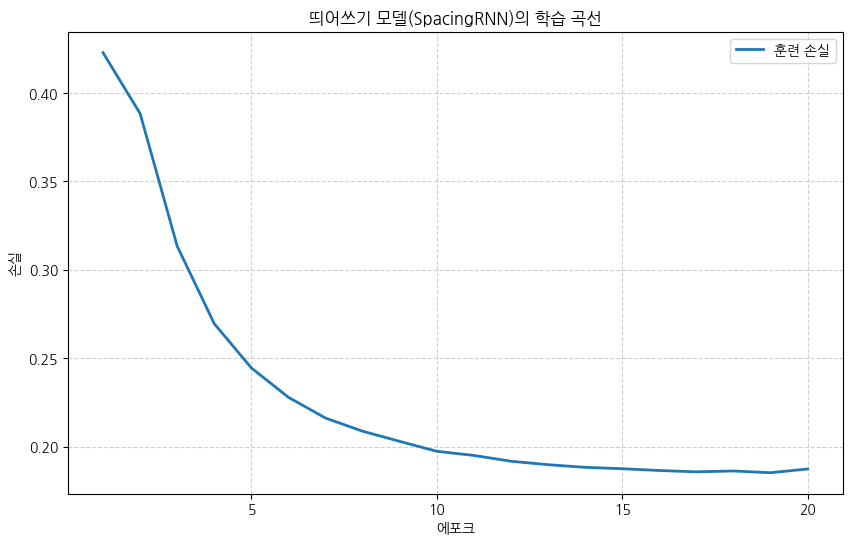

In [11]:
###############################################################################
# 코드 6-15 - 하드웨어 가속기를 사용하는 학습 함수와 띄어쓰기 모델의 학습
###############################################################################
import torch.optim as optim

# 1 에포크 학습 함수: 기울기 클리핑을 적용하고 훈련 손실의 가중 평균값을 반환
def train_epoch(model, train_loader, criterion, optimizer, device=None):
    # 하드웨어 가속기를 지정하지 않으면 CPU를 사용
    if device is None:
        device = torch.device('cpu')
    model.to(device)                        # 모델을 학습 장치로 이동
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        # 배치 텐서를 하드웨어 가속기로 이동
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()               # 기울기 초기화
        outputs = model(inputs)             # 순전파
        loss = criterion(outputs, labels)   # 손실 계산
        loss.backward()                     # 역전파
        # 기울기 클리핑: 기울기 폭주 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()                    # 최적화
        # 손실과 샘플 수 집계
        #    배치마다 샘플 수가 다를 수 있어 합산 후 마지막에 가중 평균 계산
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size           # 평균 훈련 손실 반환(가중 평균)

# 학습 하이퍼파라미터, 손실 함수, 옵티마이저
LR = 0.001                              
EPOCHS = 20                             
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_rnn.parameters(), lr=LR)

# 모델 학습
log = common.EpochLogger(EPOCHS, columns=('훈련 손실',), formats=('{:.4f}',))
for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model_rnn, spacing_dataloader, criterion, optimizer, device)
    # 학습 로그 저장 및 출력
    log.row(epoch, loss)

log.plot(title='띄어쓰기 모델(SpacingRNN)의 학습 곡선')

훈련 손실이 20 에포크에 걸쳐 감소한다. 순환 신경망의 역전파는 시간의 역순으로 같은 구조의 파라미터를 되짚어 가므로 기울기가 극단적으로 커지는 기울기 폭주가 생길 수 있는데, 기울기 클리핑으로 이를 완화한다.

## [코드 6-16] 띄어쓰기의 예측

학습된 모델로 띄어쓰기를 복원한다. 입력 문자열을 슬라이딩 윈도우로 쪼개 모델에 입력하고, 각 윈도우의 마지막 글자 뒤에 띄어쓰기가 있는지(1) 없는지(0)를 예측한다. 입력 텐서 생성에는 앞서 정의한 `SpacingDataset` 을 재사용하며, 정답은 학습에만 필요하므로 임시 가짜 정답을 사용한다.

In [12]:
###############################################################################
# 코드 6-16 - 띄어쓰기의 예측
###############################################################################
# 모델을 사용해 입력 문자열(input_string)의 띄어쓰기를 예측하는 함수
@torch.no_grad()            # 함수 전체의 연산을 추적하지 않음
def make_spacing(model, input_string, vocab, sequence_length, device=None):
    if device is None:
        device = torch.device('cpu')
    input_sequence, target_sequence = making_spacing_example(input_string)
    # SpacingDataset 클래스와 배치 크기 1인 데이터로더로 예측용 입력 텐서 생성
    dataset = SpacingDataset(
        input_sequence, target_sequence, vocab, sequence_length,
    )
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

    # 예측 결과 문자열(0 또는 1로 구성)
    spacing_sequence = ''
    model.eval()
    for input_sample, _ in dataloader:              
        input_sample = input_sample.to(device)      # 입력 텐서를 이동
        prediction = model(input_sample)            # prediction: (1, 2) 텐서
        is_spacing = torch.argmax(prediction, dim=1).item()
        spacing_sequence += str(is_spacing)

    # 앞 부분의 글자(sequence_length - 1개)는 예측 대상에서 제외
    head = input_sequence[:sequence_length - 1]
    # sequence_length 번째 글자부터 띄어쓰기 예측 결과를 반영
    tail = ''
    start_idx = sequence_length - 1
    # 0과 1의 예측 결과로부터 입력 문자열에 띄어쓰기 추가
    for i, mark in enumerate(spacing_sequence):
        tail += input_sequence[start_idx + i]
        if mark == '1':
            tail += ' '
    # 띄어쓰기 미반영한 앞 부분(head), 띄어쓰기 반영한 뒷 부분(tail) 반환
    return head, tail

In [13]:
# 참고 - 예측 결과를 본문 형태로 출력하는 result_formatting 함수
# (본문은 깃허브 노트북 참조를 안내하므로 여기서 직접 정의한다.)
def result_formatting(head, tail, original_text, width=79):
    """예측 결과(tail)를 정답과 비교해 글자 위에 X(잘못 추가)·V(누락)를 표시한다.

    - 평가 대상이 아닌 앞부분(head)은 출력하지 않는다.
    - width 칸씩 끊어, 각 텍스트 줄 위에 오답 위치를 가리키는 마커 줄을 올린다.
      · X: 넣지 말아야 할 곳에 넣은 공백(FP) → 그 공백 칸 위에 표시
      · V: 넣어야 하는데 빠뜨린 공백(FN) → 빠진 공백 바로 뒤 글자 위에 표시
    - 마지막 글자 뒤의 공백은 making_spacing_example이 정답 끝에 붙이는 인공 표시
      (문자열 끝 가정)이므로 모델의 실수가 아니다. 따라서 집계·표시에서 모두 제외한다.
    - 마지막 줄에 TP/TN/FP/FN 집계와 정확도를 출력한다.
    """
    _, norm_target = making_spacing_example(original_text)
    skip_size = len(head)               # head 부분은 평가 대상 외

    # tail에서 글자(content)와 글자 뒤 공백 예측(0/1)을 복원한다.
    # tail의 공백은 모두 모델이 추가한 것이므로 공백 유무로 예측을 알 수 있다.
    content, pred_marks = [], []
    i = 0
    while i < len(tail):
        content.append(tail[i])
        if i + 1 < len(tail) and tail[i + 1] == ' ':
            pred_marks.append(1)
            i += 2
        else:
            pred_marks.append(0)
            i += 1
    # 정답 공백(0/1)을 평가 구간(tail)의 길이에 맞춰 잘라 온다.
    target_marks = [int(c) for c in norm_target[skip_size:]][:len(pred_marks)]

    # 텍스트 줄과 마커 줄을 같은 길이로 만들며 TP/TN/FP/FN을 함께 집계한다.
    n = len(content)
    text_chars, marker_chars = [], []
    tp = tn = fp = fn = 0
    pending_v = False                   # 직전 글자에서 공백이 누락(FN)됐는가
    for j, ch in enumerate(content):
        # 글자 칸: 직전 글자에서 공백을 빠뜨렸으면 이 글자 위에 V
        marker_chars.append('V' if pending_v else ' ')
        text_chars.append(ch)
        pending_v = False
        # 마지막 글자 뒤의 공백은 문자열 끝 가정에서 온 인공 표시 → 평가·표시 제외
        if j == n - 1:
            continue
        p = pred_marks[j]
        t = target_marks[j] if j < len(target_marks) else 0
        if p == 1:                      # 공백을 넣은 경우: 공백 칸을 덧붙인다
            text_chars.append(' ')
            if t == 0:                  # 넣지 말아야 할 공백 → 위양성(FP)
                fp += 1
                marker_chars.append('X')
            else:                       # 올바르게 넣은 공백 → 진양성(TP)
                tp += 1
                marker_chars.append(' ')
        else:                           # 공백을 넣지 않은 경우
            if t == 1:                  # 넣어야 할 공백을 빠뜨림 → 위음성(FN)
                fn += 1
                pending_v = True        # 다음 글자 위에 V
            else:                       # 올바르게 붙여 씀 → 진음성(TN)
                tn += 1

    total = tp + tn + fp + fn
    acc = (tp + tn) / total * 100 if total > 0 else 0

    # width 칸씩 끊어 [마커 줄, 텍스트 줄]을 번갈아 쌓는다.
    text = ''.join(text_chars)
    marker = ''.join(marker_chars)
    lines = ['-' * width]
    for start in range(0, len(text), width):
        lines.append(marker[start: start + width])
        lines.append(text[start: start + width])
    lines.append('-' * width)
    lines.append(
        f'* TP={tp}, TN={tn}, FP(X)={fp}, FN(V)={fn} '
        f'(정확도: {tp + tn}/{total} = {acc:.1f}%)'
    )
    return '\n'.join(lines)


# 어휘 사전에 없는 문자(곱슬따옴표 등)를 미리 제거해 예외를 회피한다.
def filter_unknown_chars(text, vocab):
    lowered = text.lower()
    return ''.join(c for c in lowered if c.isspace() or c in vocab)


In [14]:
# 참고 - 모델 예측 테스트

# 테스트 입력 - 학습 데이터의 부분 문자열(첫 번째)과 포함 단어로 만든 문자열(두 번째)
test_inputs = [
    # 첫 번째 테스트 입력: 학습 데이터의 부분 문자열
    'The Witch of the South. She is the most powerful of all the Witches, '
    'and rules over the Quadlings. Besides, her castle stands on the edge '
    'of the desert, so she may know a way to cross it.',
    # 두 번째 테스트 입력: 학습 데이터에 포함되지 않은 문자열
    'It was out of sight. The Queen told them to go at once and get all '
    'her people. That would make Dorothy happy. So I will say good-bye, '
    'said the Princess.',
]

for i, test_input in enumerate(test_inputs):
    safe_input = filter_unknown_chars(test_input, vocab)
    print(f'\n-- {i + 1}번째 테스트 입력 --')
    head, tail = make_spacing(
        model_rnn, safe_input, vocab, SEQUENCE_LENGTH, device,
    )
    print(result_formatting(head, tail, safe_input))


-- 1번째 테스트 입력 --
-------------------------------------------------------------------------------
            X          X            X  X          X                            
the most pow erful of a ll the witch es , and rule s over the quadlings. beside
X                    V          V V                          VV               
 s, her castle standson the edgeofthe desert, so she may knowaway to cross it.
-------------------------------------------------------------------------------
* TP=25, TN=89, FP(X)=6, FN(V)=5 (정확도: 114/125 = 91.2%)

-- 2번째 테스트 입력 --
-------------------------------------------------------------------------------
  X      X V                                   X V                X            
to ld the mto go at once and get all her people .that would make d orothy happy
                                            
. so i will say good-bye, said the princess.
-------------------------------------------------------------------------------
* TP=21, TN=70, FP(X

결과의 X는 띄어쓰기가 잘못 추가된 위치를, V는 띄어쓰기를 해야 하지만 하지 못한 위치를 나타낸다. 본문에서 지적한 두 오류 패턴(긴 단어가 짧은 상용 단어로 잘못 분리되는 패턴, 두 단어가 붙어 분리되지 않는 패턴)이 대체로 관찰된다. 이는 25자 입력 안의 문맥을 단순 RNN이 끝까지 기억하지 못하는 구조적 한계 때문이다.

## [코드 6-17] LSTM 계층을 사용한 띄어쓰기 모델 클래스

`SpacingLSTM` 은 `SpacingRNN` 에서 `nn.RNN` 을 `nn.LSTM` 으로 교체한 것이다. 두 클래스의 외부 인터페이스(생성자 인자, 입출력 텐서 형태)가 같으므로 클래스 이름과 멤버 변수명만 바꾸면 된다. 다만 LSTM은 네 부품으로 구성되어 같은 인자 값이라도 파라미터가 더 많다.

In [15]:
###############################################################################
# 코드 6-17 - LSTM 계층을 사용한 띄어쓰기 모델 클래스
###############################################################################
# LSTM 계층(self.lstm)과 완전 연결 계층(self.fc)으로 구성된 LSTM 모델 클래스
class SpacingLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        # 단순 RNN 계층을 LSTM 계층으로 교체
        #     LSTM과 단순 RNN의 생성자 인자 및 첫 번째 출력은 같음
        self.lstm = nn.LSTM(            # LSTM 계층 블록
            input_size=input_size,      # 어휘 사전의 크기(각 토큰 벡터의 크기)
            hidden_size=hidden_size,    # 숨겨진 상태(단기 기억)의 크기
            num_layers=num_layers,      # LSTM 블록의 수직 배치 계수
            batch_first=True,           # (B, S, input_size) 형태의 입력
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):               # x: (B, S, input_size)
        outputs, _ = self.lstm(x)       #    -> (B, S, hidden_size)
        # [:, -1, :] 슬라이싱으로 마지막 시점의 숨겨진 상태 선택(nn.RNN과 동일)
        last_hidden = outputs[:, -1, :] #    -> (B, hidden_size)
        return self.fc(last_hidden)     #    -> (B, output_size)

## 단순 RNN 모델과 LSTM 모델의 학습 곡선·예측 비교

본문은 [코드 6-17] 이후 두 모델의 학습 코드를 생략하고 학습 곡선([그림 6-11])과 예측 결과 비교만 보여준다. 여기서는 동일한 학습 설정으로 `SpacingLSTM` 을 학습한 뒤 학습 곡선과 예측 결과를 비교한다.

epoch    훈련 손실     시간
 1/20       0.3564     0:10
 2/20       0.2462     0:20
 4/20       0.1875     0:40
 6/20       0.1517     1:00
 8/20       0.1217     1:19
10/20       0.0930     1:39
12/20       0.0687     1:59
14/20       0.0494     2:19
16/20       0.0364     2:38
18/20       0.0299     2:57
20/20       0.0263     3:17


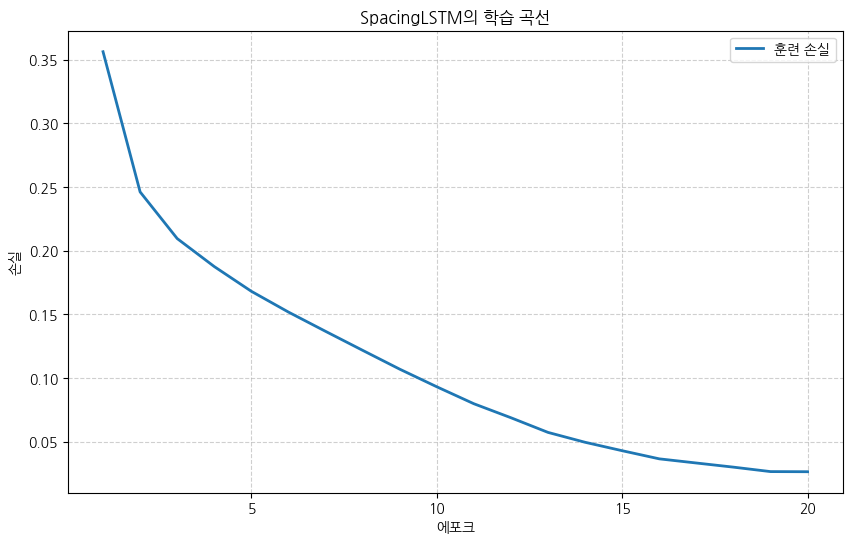

In [16]:
# 참고 - SpacingLSTM 학습 (재현성을 위해 시드 재설정 후 동일 설정으로 학습)
common.set_seed()

model_lstm = SpacingLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=LR)
model_lstm.to(device)
log_lstm = common.EpochLogger(EPOCHS, columns=('훈련 손실',), 
                              formats=('{:.4f}',))
for epoch in range(1, EPOCHS + 1):
    loss_lstm = train_epoch(model_lstm, spacing_dataloader, criterion, 
                            optimizer, device)
    log_lstm.row(epoch, loss_lstm)
log_lstm.plot(title='SpacingLSTM의 학습 곡선')


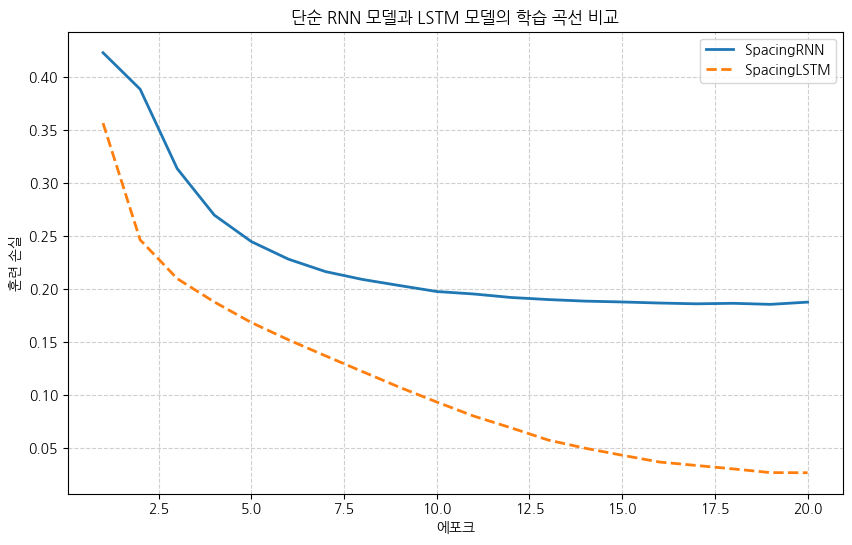

In [17]:
# 그림 6-11 - 두 모델의 학습 곡선 비교
viz.plot_histories(
    {
        'SpacingRNN': log.history['훈련 손실'],
        'SpacingLSTM': log_lstm.history['훈련 손실'],
    },
    title='단순 RNN 모델과 LSTM 모델의 학습 곡선 비교',
    y_label='훈련 손실',
)

In [18]:
# 참고 - SpacingLSTM 예측 결과
for i, test_input in enumerate(test_inputs):
    safe_input = filter_unknown_chars(test_input, vocab)
    print(f'\n-- {i + 1}번째 테스트 입력 --')
    head, tail = make_spacing(
        model_lstm, safe_input, vocab, SEQUENCE_LENGTH, device,
    )
    print(result_formatting(head, tail, safe_input))


-- 1번째 테스트 입력 --
-------------------------------------------------------------------------------
                                                                               
the most powerful of all the witches, and rules over the quadlings. besides, he
                                                                             
r castle stands on the edge of the desert, so she may know a way to cross it.
-------------------------------------------------------------------------------
* TP=30, TN=95, FP(X)=0, FN(V)=0 (정확도: 125/125 = 100.0%)

-- 2번째 테스트 입력 --
-------------------------------------------------------------------------------
        X                                                                      
told the m to go at once and get all her people. that would make dorothy happy.
V                 X    X                   X 
so i will say good -bye , said the princess .
-------------------------------------------------------------------------------
* TP=22, TN=70, FP(

## 정리

- 띄어쓰기 문제는 윈도우 마지막 글자 다음에 띄어쓰기가 있는지(0/1)를 예측하는 이진 분류 문제로 변환할 수 있다.
- 순환 신경망의 기울기 폭주를 막기 위해 학습 루프에 기울기 클리핑(`clip_grad_norm_`)을 적용한다.
- LSTM은 단순 RNN과 외부 인터페이스가 같아 `nn.RNN` 을 `nn.LSTM` 으로 바꾸기만 하면 되며, 장기 의존성을 더 잘 활용해 긴 문맥이 필요한 띄어쓰기 문제에서 성능이 더 좋다. 더 가벼운 변형인 `nn.GRU` 도 같은 방식으로 교체해 쓸 수 있다.

## 참고 - [그림 6-12] 과적합을 보여주는 학습 곡선

본문은 [코드 6-17] 이후 코드를 싣지 않고 학습 곡선([그림 6-12])만 보여준다. 여기서는 데이터의 20%를 검증 데이터로 분리해 `SpacingLSTM` 을 학습하면서 에포크마다 훈련 손실, 검증 손실, 검증 F1 점수를 함께 기록한다.

순차 데이터는 슬라이딩 윈도우가 만든 인접 샘플이 부분 문자열을 공유하므로, `random_split()` 으로 윈도우 샘플을 무작위 분리하면 훈련·검증 데이터에 정보가 중복돼 일반화 성능을 제대로 평가할 수 없다. 그래서 **윈도우를 적용하기 전 원본 순차 데이터를 8:2로 먼저 나눈 뒤** 각 덩어리에서 데이터셋을 만들고, 검증 데이터에 훈련 때 보지 못한 토큰이 나타나는 예외를 피하려고 통합 어휘 사전(`vocab`)을 공유한다.

띄어쓰기(양성, 1)는 전체 위치의 일부에 불과한 불균형 분류이므로 정확도 대신 **F1 점수**로 검증한다. 훈련 손실은 계속 줄지만 검증 F1 점수는 정점을 지나 오히려 떨어지는데, 이는 과적합이 진행 중이라는 신호다.

epoch    훈련 손실    검증 손실  검증 F1 점수     시간
 1/20       0.3784       0.3152        0.6603     0:09
 2/20       0.2597       0.2901        0.7185     0:18
 3/20       0.2192       0.2699        0.7111     0:28
 4/20       0.1951       0.2571        0.7274     0:37
 5/20       0.1760       0.2565        0.7415     0:46
 6/20       0.1602       0.2519        0.7635     0:55
 7/20       0.1445       0.2582        0.7617     1:04
 8/20       0.1292       0.2752        0.7600     1:13
 9/20       0.1143       0.2878        0.7517     1:22
10/20       0.0994       0.3243        0.7564     1:31
11/20       0.0856       0.3357        0.7555     1:40
------------------------------------------------------
전체 학습 시간 1:40 · (조기 종료: 검증 F1 점수가 5 에포크 동안 개선되지 않음)
검증 F1 점수가 가장 높은 에포크: 6 (F1=0.7635)


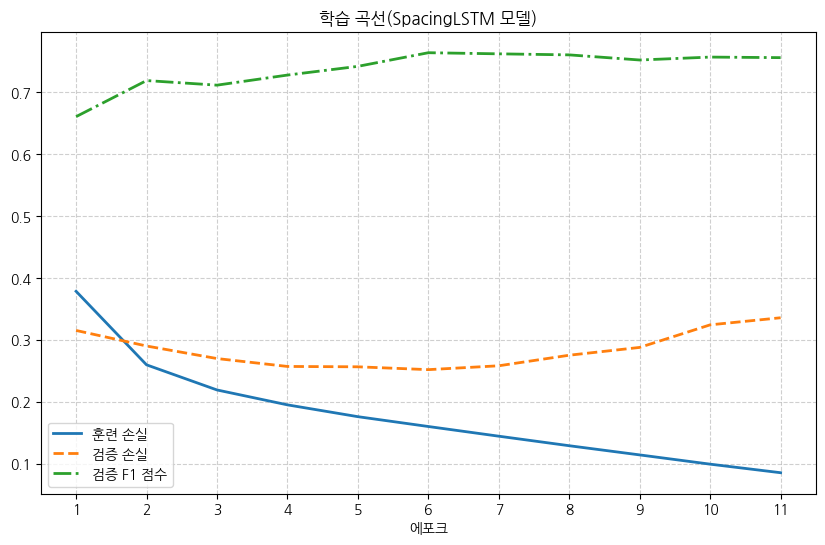

In [19]:
# [그림 6-12] - 검증 데이터를 분리하고 조기 종료로 SpacingLSTM 학습
@torch.no_grad()
def evaluate_spacing(model, loader, criterion, device):
    """검증 손실과 띄어쓰기(양성=1) F1 점수를 함께 반환한다."""
    model.eval()
    loss_sum, sample_size = 0.0, 0
    tp = fp = fn = 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss_sum += criterion(outputs, labels).item() * inputs.size(0)
        sample_size += inputs.size(0)
        preds = outputs.argmax(dim=1)
        # 띄어쓰기(양성=1)에 대한 TP/FP/FN 집계
        tp += int(((preds == 1) & (labels == 1)).sum())
        fp += int(((preds == 1) & (labels == 0)).sum())
        fn += int(((preds == 0) & (labels == 1)).sum())
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return loss_sum / sample_size, f1


# 재현성을 위해 시드 재설정
common.set_seed()

# 1) 원본 순차 데이터를 8:2로 분리 (윈도우 적용 전에 나눠 정보 누수 방지)
split_idx = int(len(input_sequence) * 0.8)
train_input, valid_input = input_sequence[:split_idx], input_sequence[split_idx:]
train_target, valid_target = target_sequence[:split_idx], target_sequence[split_idx:]

# 2) 통합 어휘 사전(vocab)을 공유해 데이터셋과 데이터로더 생성 (미등장 토큰 예외 방지)
train_dataset = SpacingDataset(train_input, train_target, vocab, SEQUENCE_LENGTH)
valid_dataset = SpacingDataset(valid_input, valid_target, vocab, SEQUENCE_LENGTH)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3) 모델, 손실 함수, 옵티마이저
model_es = SpacingLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_es.parameters(), lr=LR)

# 4) 에포크마다 검증 지표를 기록하고, 검증 F1 점수 기준으로 조기 종료
PATIENCE = 5                            # 검증 F1이 개선되지 않아도 기다리는 에포크 수
log = common.EpochLogger(
    EPOCHS,
    columns=('훈련 손실', '검증 손실', '검증 F1 점수'),
    formats=('{:.4f}', '{:.4f}', '{:.4f}'),
    minimize='검증 F1 점수',           # 손실 열이 아니므로 요약의 '최적 에포크'는 생략된다
    target_rows=EPOCHS
)
best_f1, best_epoch, best_state, wait, stopped = -1.0, 0, None, 0, None
for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model_es, train_loader, criterion, optimizer, device)
    valid_loss, valid_f1 = evaluate_spacing(model_es, valid_loader, criterion, device)
    log.row(epoch, train_loss, valid_loss, valid_f1)
    if valid_f1 > best_f1:              # F1은 클수록 좋으므로 최댓값을 추적
        best_f1, best_epoch, wait = valid_f1, epoch, 0
        best_state = {k: v.detach().cpu().clone()
                      for k, v in model_es.state_dict().items()}
    else:
        wait += 1
        if wait >= PATIENCE:
            stopped = f'조기 종료: 검증 F1 점수가 {PATIENCE} 에포크 동안 개선되지 않음'
            break
log.summary(stopped=stopped)
if best_state is not None:
    model_es.load_state_dict(best_state)   # 검증 F1이 가장 높았던 가중치로 복원
print(f'검증 F1 점수가 가장 높은 에포크: {best_epoch} (F1={best_f1:.4f})')

# 5) 학습 곡선 시각화 ([그림 6-12])
# 훈련 손실은 계속 줄지만 검증 F1 점수는 정점을 지나 하락 -> 과적합 신호
viz.plot_histories(
    {
        '훈련 손실': log.history['훈련 손실'],
        '검증 손실': log.history['검증 손실'],
        '검증 F1 점수': log.history['검증 F1 점수'],
    },
    title='학습 곡선(SpacingLSTM 모델)',
    y_label=None,
    x_ticks=log.epochs_seen,
)


In [20]:
for i, test_input in enumerate(test_inputs):
    safe_input = filter_unknown_chars(test_input, vocab)
    print(f'\n-- {i + 1}번째 테스트 입력 --')
    head, tail = make_spacing(
        model_es, safe_input, vocab, SEQUENCE_LENGTH, device,
    )
    print(result_formatting(head, tail, safe_input))


-- 1번째 테스트 입력 --
-------------------------------------------------------------------------------
                      X                                           X          X 
the most powerful of a ll the witches, and rules over the quadling s. besides ,
                 X             V                               V              X
 her castle stand s on the edgeof the desert, so she may know away to cross it 
 
.
-------------------------------------------------------------------------------
* TP=28, TN=90, FP(X)=5, FN(V)=2 (정확도: 118/125 = 94.4%)

-- 2번째 테스트 입력 --
-------------------------------------------------------------------------------
               V                             X                               X 
told them to goat once and get all her people . that would make dorothy happy .
                   X          V          X X 
 so i will say good -bye, saidthe princes s .
-------------------------------------------------------------------------------
* TP=21, TN=